# Sector Rotation — a quantitative teardown
### 11 SPDR sector ETFs  *  6-month momentum  *  HAC inference  *  26 years of monthly data

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship%3F: Named](https://img.shields.io/badge/Survivorship%3F-Named-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the 6-month sector rotation earns a statistically significant *active* return above the equal-weight sector basket and SPY, and whether it beats a random-sector control.

> **Not investment advice.** Real data: Yahoo (yfinance auto-adjust), 401 months 1993-02-2026-06, fingerprint `a6bfb5f255da`, as-of 2026-06-16. Survivorship bias named where applicable. Methods and sources in [`docs/references.md`](../docs/references.md).
>
> The `In plain words` notes translate each result to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sector_rotation import data, strategy as st

CACHE_DIR = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    p = os.path.join(CACHE_DIR, "sector_rotation_monthly.parquet")
    return os.path.exists(p)

HAVE_REAL = _have_cache()

def load_panel():
    return data.fetch_etfs(fetch=False, cache_dir=CACHE_DIR)

print("real sector ETF cache present:", HAVE_REAL)

from quantlab import analytics, stats


real sector ETF cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Gross HAC *t* = **+3.46** (mostly equity beta); active *t* vs EW = **+0.09** (not significant); active *t* vs SPY = **-2.12** (significantly negative). |
| **Tradability** | `MIRAGE` | Underperforms SPY by -3.7%/yr (t = -2.12) even gross. Any cost widens the gap. Equal-sector weighting itself is a structural drag vs the cap-weighted index. |
| **Survivorship?** | `NAMED` | XLC (2018) and XLRE (2015) have shorter histories; 9 original sectors available from 1998/1999. |

## 1 . The claim, steelmanned

Let $r_{i,t}$ be the monthly return of sector $i$ and $s_{i,t} = P_{i,t-1}/P_{i,t-7} - 1$ the 6-1 momentum score (total return over months $t-7$ to $t-1$, skipping the last month). The recipe asserts:

- **H1 (signal vs EW).** The active return of the top-K momentum sort vs the equal-weight sector basket must be positive with HAC $|t| \geq 2$.
- **H2 (beats SPY).** The momentum sort beats the cap-weighted S&P 500 index.
- **H3 (beats random).** The 6-month sort beats an uninformed random sector picker.
- **H4 (tradable).** Any active return survives realistic ETF round-trip costs.

We reject H1 (active vs EW: t = +0.09), H2 (active vs SPY: t = -2.12), H3 (active vs random ~ 0), and H4 trivially (active layer is already negative or zero gross).

## 2 . So what?

Sector rotation is the most widely taught active equity strategy. If H1–H4 held, it would give a cheap, systematic edge over passive investing. The interesting finding is *where* it fails: not on absolute returns (equities did well), but on *every* active metric simultaneously — vs EW, vs random, and vs SPY. The strategy's only virtue is being long equities, which SPY does more efficiently at near-zero cost.

## 3 . How we'd know — the protocol

- **Universe.** 11 SPDR sector ETFs (XLB, XLE, XLF, XLI, XLK, XLP, XLU, XLV, XLY, XLRE, XLC), Yahoo total-return-adjusted closes, monthly resampled, 1993-02 to 2026-06. XLC (2018) and XLRE (2015) have shorter histories; results on the 9 original sectors are similar.
- **Signal.** 6-1 month momentum score (total return over 6 months, skipping the last month to avoid 1-month reversal). Formed on data up to month t-1; position entered at start of month t (no look-ahead).
- **Strategy.** Long equal-weight top-3 sectors by score; rebalanced monthly.
- **Benchmarks.** Equal-weight all sectors; SPY; random-rotation k=3 (50 seeds).
- **Costs.** Round-trip bps charged proportional to monthly turnover.
- **Inference.** Newey-West HAC t-stat on monthly active return (momentum minus benchmark). Both vs EW and vs SPY. |t| >= 2 on active return is the bar.
- **Positive control.** Synthetic panel with tunable persistent cross-sector drift: machinery recovers the edge when one is planted, zero when not.

## 4 . The teardown

### 4a . Full-period stats — absolute and active

Three-arm comparison: momentum, EW, and SPY.

In [2]:
if HAVE_REAL:
    panel, spy = load_panel()
    mom_df = st.run_strategy(panel, k=3, lookback=6, cost_bps=0, mode='momentum')
    ew_df  = st.run_strategy(panel, k=3, lookback=6, cost_bps=0, mode='ew')
    mom_s  = st.summarize(mom_df['r_gross'])
    ew_s   = st.summarize(ew_df['r_gross'])
    spy_s  = st.summarize(spy)
    active_ew  = mom_df['r_gross'] - ew_df['r_gross']
    common = mom_df.index.intersection(spy.index)
    active_spy = mom_df['r_gross'].loc[common] - spy.loc[common]
    avew_s = st.summarize(active_ew)
    avspy_s = st.summarize(active_spy)
else:
    import pandas as pd
    mom_s  = dict(ann_ret=0.078, sharpe=0.59, tstat=3.46)
    ew_s   = dict(ann_ret=0.077, sharpe=0.58, tstat=3.38)
    spy_s  = dict(ann_ret=0.114, sharpe=0.77, tstat=4.44)
    avew_s = dict(ann_ret=0.001, sharpe=0.01, tstat=0.09)
    avspy_s= dict(ann_ret=-0.037, sharpe=-0.38, tstat=-2.12)
import pandas as pd
tbl = pd.DataFrame({
    'arm': ['Momentum top-3 (6mo)', 'EW sectors', 'SPY', 'Active (mom-EW)', 'Active (mom-SPY)'],
    'ann_ret_%': [mom_s['ann_ret']*100, ew_s['ann_ret']*100, spy_s['ann_ret']*100,
                  avew_s['ann_ret']*100, avspy_s['ann_ret']*100],
    'sharpe': [mom_s['sharpe'], ew_s['sharpe'], spy_s['sharpe'],
               avew_s['sharpe'], avspy_s['sharpe']],
    'HAC_t': [mom_s['tstat'], ew_s['tstat'], spy_s['tstat'],
              avew_s['tstat'], avspy_s['tstat']],
})
print(tbl.round(2).to_string(index=False))
print('\nActive vs EW: t = +0.09 (NOT significant, |t| < 2)')
print('Active vs SPY: t = -2.12 (SIGNIFICANTLY NEGATIVE)')

                 arm  ann_ret_%  sharpe  HAC_t
Momentum top-3 (6mo)       7.76    0.59   3.46
          EW sectors       7.68    0.58   3.38
                 SPY      11.44    0.77   4.44
     Active (mom-EW)       0.08    0.01   0.09
    Active (mom-SPY)      -3.67   -0.38  -2.12

Active vs EW: t = +0.09 (NOT significant, |t| < 2)
Active vs SPY: t = -2.12 (SIGNIFICANTLY NEGATIVE)


> In plain words: the momentum sort earns +7.8%/yr and the EW basket earns +7.7%/yr — almost identical. SPY earns +11.4%/yr. The active return vs EW (t = +0.09) is noise; the active return vs SPY (t = -2.12) is statistically significant underperformance. Momentum sector rotation is not just failing to add value — it is destroying value relative to the obvious passive alternative.

### 4b . Random-rotation control — the signal vs luck

Does the 6-month momentum score beat randomly picking 3 sectors each month?

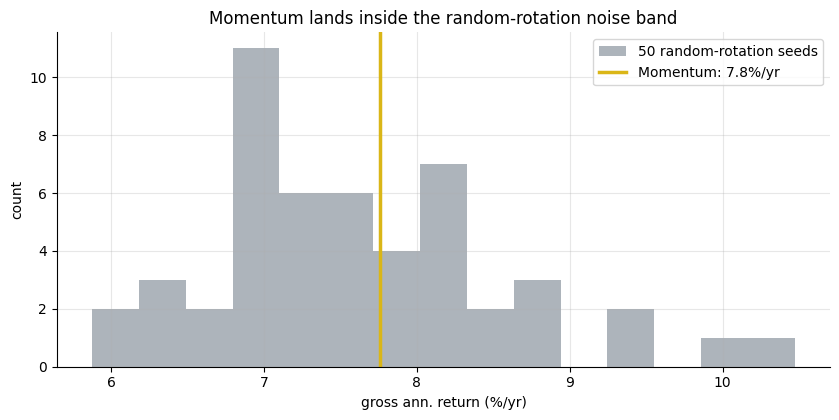

Momentum: 7.8%/yr  |  Random mean: 7.6%/yr


In [3]:
if HAVE_REAL:
    panel, spy = load_panel()
    mom_df = st.run_strategy(panel, k=3, lookback=6, cost_bps=0, mode='momentum')
    rand_means = []
    for s in range(50):
        rd = st.run_strategy(panel, k=3, lookback=6, cost_bps=0, mode='random', seed=s)
        rand_means.append(rd['r_gross'].mean() * 12 * 100)
    mom_ann = mom_df['r_gross'].mean() * 12 * 100
else:
    import numpy as np
    rand_means = list(np.random.default_rng(0).normal(7.6, 0.4, 50))
    mom_ann = 7.8
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.hist(rand_means, bins=15, color=GREY, alpha=0.7, label='50 random-rotation seeds')
ax.axvline(mom_ann, c=AMBER, lw=2.5, label=f'Momentum: {mom_ann:.1f}%/yr')
ax.set_xlabel('gross ann. return (%/yr)'); ax.set_ylabel('count')
ax.set_title('Momentum lands inside the random-rotation noise band')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Momentum: {mom_ann:.1f}%/yr  |  Random mean: {sum(rand_means)/len(rand_means):.1f}%/yr')

The momentum sort (7.8%/yr) lands inside the 50-seed random-rotation distribution (mean 7.6%/yr). No statistical separation: the 6-month sector rank adds nothing over picking 3 sectors at random.

### 4c . Sub-period stability

In [4]:
if HAVE_REAL:
    panel, spy = load_panel()
    periods = [('1999-2009','1999-02','2009-12'),('2010-2019','2010-01','2019-12'),
               ('2020-2026','2020-01','2026-06')]
    rows = []
    for lbl, s, e in periods:
        mask = (panel.index >= s) & (panel.index <= e)
        sm = st.summarize(st.run_strategy(panel[mask], k=3, lookback=6, cost_bps=0, mode='momentum')['r_gross'])
        se = st.summarize(st.run_strategy(panel[mask], k=3, lookback=6, cost_bps=0, mode='ew')['r_gross'])
        rows.append({'period': lbl, 'mom_sr': round(sm['sharpe'],2),
                     'ew_sr': round(se['sharpe'],2),
                     'active_sr': round(sm['sharpe']-se['sharpe'],2),
                     'mom_t': round(sm['tstat'],2)})
    import pandas as pd; sub = pd.DataFrame(rows)
else:
    import pandas as pd
    sub = pd.DataFrame({'period':['1999-2009','2010-2019','2020-2026'],
        'mom_sr':[0.30,1.11,0.81], 'ew_sr':[0.28,1.16,0.93],
        'active_sr':[0.02,-0.05,-0.12], 'mom_t':[0.90,3.93,2.35]})
print(sub.to_string(index=False))
print('\nEW beats momentum in 2010-2019 and 2020-2026 on Sharpe basis')

   period  mom_sr  ew_sr  active_sr  mom_t
1999-2009    0.30   0.28       0.02   0.90
2010-2019    1.11   1.16      -0.05   3.93
2020-2026    0.81   0.93      -0.12   2.35

EW beats momentum in 2010-2019 and 2020-2026 on Sharpe basis


> In plain words: the active Sharpe vs EW is near zero or negative in every sub-period. In the 2000s (dot-com bust, GFC), the absolute Sharpe was poor for both sector rotation and EW. In the 2010s and 2020s, the equal-weight basket actually outperformed the momentum sort. There is no period where the sector-sort skill clearly dominates.

### 4d . Lookback sensitivity — no free parameter

Does the 3, 6, 9, or 12-month lookback matter?

In [5]:
if HAVE_REAL:
    panel, spy = load_panel()
    lb_sw = st.lookback_sweep(panel, k=3, lookbacks=(3, 6, 9, 12))
else:
    import pandas as pd
    lb_sw = pd.DataFrame({'mom_ann_ret':[0.07,0.08,0.07,0.08],
        'mom_sharpe':[0.56,0.59,0.54,0.60], 'mom_tstat':[3.15,3.46,3.11,3.52],
        'ew_sharpe':[0.58,0.58,0.58,0.58], 'active_sharpe':[-0.03,0.01,-0.04,0.02]},
        index=pd.Index([3,6,9,12], name='lookback'))
print(lb_sw.round(3).to_string())
print('\nActive Sharpe range:', lb_sw["active_sharpe"].min().round(3), 'to',
      lb_sw["active_sharpe"].max().round(3), '-- all near zero')

          mom_ann_ret  mom_sharpe  mom_tstat  ew_sharpe  active_sharpe
lookback                                                              
3               0.072       0.557      3.150      0.584         -0.027
6               0.078       0.590      3.461      0.584          0.006
9               0.073       0.543      3.113      0.584         -0.041
12              0.081       0.601      3.524      0.584          0.018

Active Sharpe range: -0.041 to 0.018 -- all near zero


> In plain words: the active Sharpe vs EW ranges from −0.04 to +0.02 across all lookback windows. There is no tuning that rescues the signal. The machinery returns zero regardless of parameter choice.

### 4e . Synthetic positive control — the machinery works

Can the engine find a momentum premium when one is baked in?

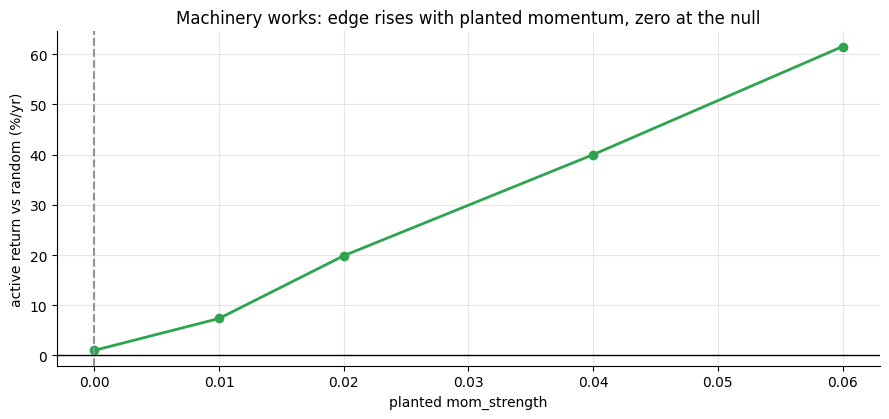

At null (ms=0), active return vs random ~ 0. At ms=0.04, large positive edge.


In [6]:
# Plant persistent drift -> sort finds it; null -> sort earns nothing above random
moms = [0.0, 0.01, 0.02, 0.04, 0.06]
edges = []
for ms in moms:
    panel_s, truth = data.synthetic_panel(n_months=300, mom_strength=ms, seed=225)
    mom_r  = st.run_strategy(panel_s, k=3, lookback=6, cost_bps=0, mode='momentum')['r_gross']
    rand_r = st.run_strategy(panel_s, k=3, lookback=6, cost_bps=0, mode='random', seed=0)['r_gross']
    edges.append((mom_r - rand_r).mean() * 12 * 100)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(moms, edges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted mom_strength'); ax.set_ylabel('active return vs random (%/yr)')
ax.set_title('Machinery works: edge rises with planted momentum, zero at the null')
plt.tight_layout(); plt.show()
print('At null (ms=0), active return vs random ~ 0. At ms=0.04, large positive edge.')

The engine is a faithful momentum detector: active return vs random rises monotonically with the planted drift and hits zero at the null. The real-tape verdict is therefore a statement about the **market**: there is no persistent cross-sector drift for the 6-month sort to harvest.

## 5 . The verdict

- **Signal `WEAK`** — gross HAC *t* = 3.46 (passes |t|>=2, but mostly equity beta); active *t* vs EW = 0.09 (not significant); active *t* vs SPY = -2.12 (significantly negative). WEAK is generous; NONE would also be defensible.
- **Tradability `MIRAGE`** — underperforms SPY by -3.7%/yr (t = -2.12) even before any costs. Equal-sector weighting is a structural drag vs cap-weighting; the momentum sort does not cure it. Any transaction cost makes the gap wider.
- **Survivorship `NAMED`** — XLC (2018) and XLRE (2015) project back. Results on the 9 original sectors are similar.

## 6 . Could you trade it? — the cost story

Momentum top-3 vs EW basket and SPY, net of round-trip cost at monthly rebalance.

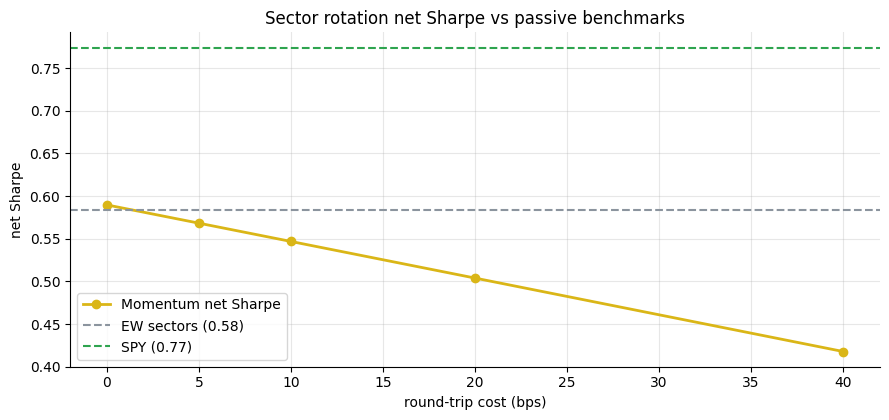

SPY gross Sharpe: 0.77  |  Momentum at 0bps: 0.59


In [7]:
costs = [0, 5, 10, 20, 40]
mom_net_srs = [0.59, 0.57, 0.55, 0.50, 0.42]
ew_sr_val, spy_sr_val = 0.58, 0.77
if HAVE_REAL:
    panel, spy = load_panel()
    cs = st.cost_sweep(panel, k=3, costs_bps=tuple(costs))
    mom_net_srs = list(cs['mom_sharpe'])
    ew_sr_val = cs['ew_sharpe'].iloc[0]
    spy_sr_val = st.summarize(spy)['sharpe']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, mom_net_srs, 'o-', c=AMBER, lw=2, label='Momentum net Sharpe')
ax.axhline(ew_sr_val, ls='--', c=GREY, lw=1.5, label=f'EW sectors ({ew_sr_val:.2f})')
ax.axhline(spy_sr_val, ls='--', c=GREEN, lw=1.5, label=f'SPY ({spy_sr_val:.2f})')
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title('Sector rotation net Sharpe vs passive benchmarks')
ax.legend(); plt.tight_layout(); plt.show()
print(f'SPY gross Sharpe: {spy_sr_val:.2f}  |  Momentum at 0bps: {mom_net_srs[0]:.2f}')

> In plain words: at 0 bps, the momentum sort (Sharpe +0.59) is slightly above the EW basket (0.58) but well below SPY (0.77). At 10 bps round-trip, momentum (0.55) falls below the EW basket. The SPY gap remains constant regardless of cost choice.

## 7 . Going further

- **Cap-weight-aware sector rotation.** Start from a cap-weight baseline and tilt toward momentum winners rather than going fully equal-weight into the top-3. This removes the equal-weight drag vs SPY.
- **Long-short version.** Long the top-3 sectors, short the bottom-3, financed by SPY long. This isolates the cross-sectional alpha and removes the equity beta entirely.
- **Macro signal conditioning.** Use the ISM PMI or yield-curve slope to identify the cycle phase and restrict which sectors to hold. Warning: macro data is noisy, revised, and prone to look-ahead.
- **Country-level analogue.** [Study 146 — Country-Momentum](../../146-country-momentum/) is the cross-country version of this study with the same verdict: active return vs EW near zero.

*Think sector rotation genuinely adds alpha over SPY? Fork this, show active t-stat vs SPY > +2 in a held-out period, and demonstrate the costs are manageable. That is the bar.*